# RQ0. Perfilado de calidad de datos

**Fase CRISP-DM 2: comprensión de los datos.** Antes de analizar, caracterizamos
cobertura temporal, huecos, outliers y particularidades del universo de 24 activos
y 4 series macro. Las conclusiones de este notebook definen qué activos participan
en cada análisis posterior (RQ1-RQ5).

Este notebook no contrasta hipótesis: produce el inventario de validez del que
dependen todos los demás.

In [1]:
import sys
from pathlib import Path

if str(Path.cwd().parent) not in sys.path:
    sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import pandas as pd

from src.db import get_engine

eng = get_engine()
pd.options.display.float_format = "{:.4f}".format

## 1. Cobertura temporal por activo

¿Desde cuándo hay datos de cada activo? Esto determina qué ventanas de análisis
son posibles: un backtest de 20 años exige al menos 240 meses de historia.

In [2]:
cov = pd.read_sql(
    "SELECT ticker, asset_type, first_date, last_date FROM dim_asset ORDER BY first_date",
    eng)
cov["years"] = (pd.to_datetime(cov["last_date"]) - pd.to_datetime(cov["first_date"])).dt.days / 365.25
cov

,ticker,asset_type,first_date,last_date,years
0,XOM,stock,1962-01-02,2026-07-10,64.5175
1,JNJ,stock,1962-01-02,2026-07-10,64.5175
2,JPM,stock,1980-03-17,2026-07-10,46.3135
3,AAPL,stock,1980-12-12,2026-07-10,45.5743
4,MSFT,stock,1986-03-13,2026-07-10,40.3258
5,SPY,etf_core,1993-01-29,2026-07-10,33.4428
6,XLY,etf_sector,1998-12-22,2026-07-10,27.5483
7,XLF,etf_sector,1998-12-22,2026-07-10,27.5483
8,XLE,etf_sector,1998-12-22,2026-07-10,27.5483
9,XLV,etf_sector,1998-12-22,2026-07-10,27.5483


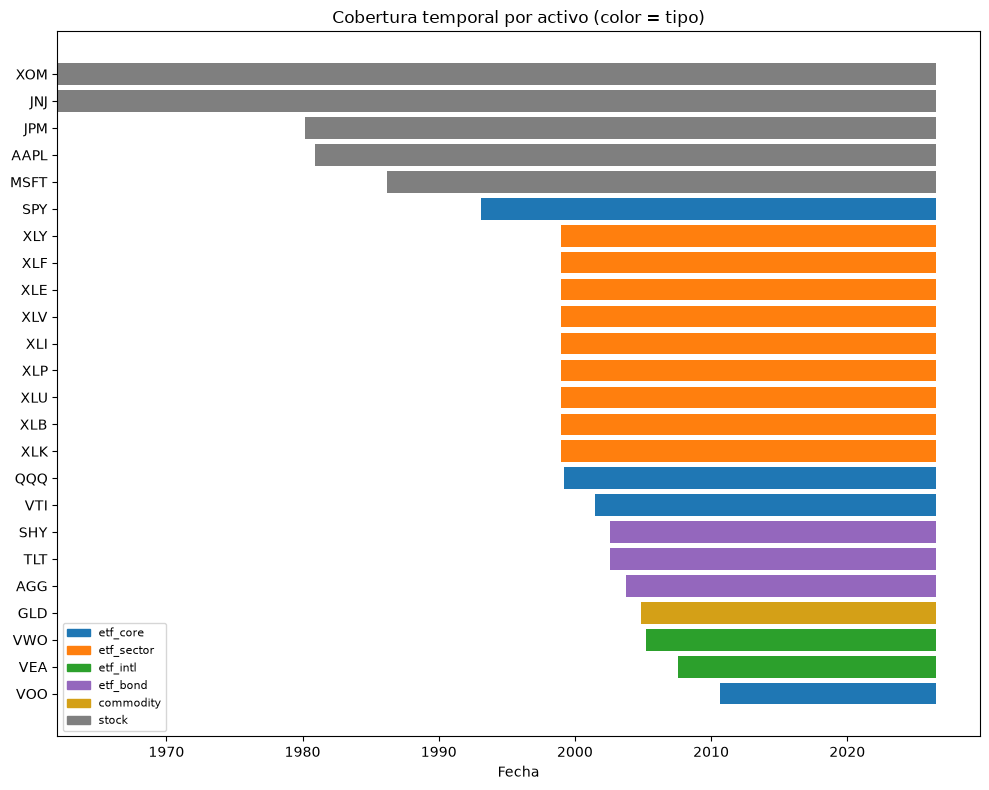

In [3]:
fig, ax = plt.subplots(figsize=(10, 8))
colors = {"etf_core": "#1f77b4", "etf_sector": "#ff7f0e", "etf_intl": "#2ca02c",
          "etf_bond": "#9467bd", "commodity": "#d4a017", "stock": "#7f7f7f"}
for i, row in cov.iterrows():
    ax.barh(row["ticker"], (pd.to_datetime(row["last_date"]) - pd.to_datetime(row["first_date"])).days,
            left=pd.to_datetime(row["first_date"]), color=colors[row["asset_type"]])
ax.set_title("Cobertura temporal por activo (color = tipo)")
ax.set_xlabel("Fecha")
ax.invert_yaxis()
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in colors.values()]
ax.legend(handles, colors.keys(), loc="lower left", fontsize=8)
plt.tight_layout()
plt.show()

**Lectura.** Las acciones individuales (XOM, JNJ desde 1962) y SPY (1993) tienen la
historia más profunda. Los 9 ETFs sectoriales SPDR nacen juntos en diciembre de 1998.
VOO existe solo desde 2010: para ventanas largas del S&P 500 el proxy es SPY, que
replica el mismo índice. VEA (2007) queda al borde de las ventanas de 20 años.

## 2. Huecos de calendario

Días hábiles donde SPY cotizó pero otro activo (ya listado) no tiene precio.
Un conteo alto indicaría datos incompletos en la fuente.

In [4]:
gaps = pd.read_sql("""
    WITH spy_days AS (SELECT date FROM v_daily_returns WHERE ticker='SPY')
    SELECT a.ticker, count(*) AS missing_days
    FROM spy_days s
    CROSS JOIN dim_asset a
    LEFT JOIN fact_price_daily f ON f.asset_id = a.asset_id AND f.date = s.date
    WHERE f.date IS NULL AND s.date >= a.first_date
    GROUP BY a.ticker HAVING count(*) > 0 ORDER BY missing_days DESC
""", eng)
print("Activos con huecos:", len(gaps))
gaps

Activos con huecos: 0


,ticker,missing_days


**Lectura.** Cero huecos: cada activo tiene precio en todos los días hábiles del
calendario de SPY desde su fecha de listado. La fuente es consistente.

## 3. Outliers de retorno diario

Retornos diarios con magnitud mayor al 20%. Cada caso se inspecciona: ¿error de
datos (split mal ajustado) o evento real de mercado?

In [5]:
outliers = pd.read_sql("""
    SELECT ticker, date, round(ret::numeric, 4) AS ret
    FROM v_daily_returns WHERE abs(ret) > 0.2 ORDER BY date
""", eng)
outliers

,ticker,date,ret
0,AAPL,1983-09-23,-0.2538
1,XOM,1987-10-19,-0.2343
2,AAPL,1987-10-19,-0.2435
3,MSFT,1987-10-19,-0.3012
4,JPM,1987-10-19,-0.2772
5,AAPL,1987-10-26,-0.2113
6,AAPL,1993-07-16,-0.2308
7,AAPL,1996-07-18,0.2370
8,AAPL,1997-08-06,0.3323
9,AAPL,1998-01-02,0.2381


**Lectura.** Los 18 outliers corresponden a eventos documentados, no a errores:

- **1987-10-19/21**: lunes negro y rebote (MSFT, XOM, JPM, AAPL).
- **1983-1997 en AAPL**: alta volatilidad idiosincrática de sus primeros años
  (resultados trimestrales; incluye -25% en 1987).
- **2000-09-29 en AAPL**: profit warning, -52% en un día. Real.
- **2008-2009 en JPM, VWO**: crisis financiera global.
- **2020-03-09 en XLE**: colapso del petróleo por COVID y guerra de precios OPEP.

No se elimina ningún dato: son retornos verídicos que los análisis deben soportar
(por eso RQ1-RQ5 usan bootstrap en bloques y no asumen normalidad).

## 4. Dividendos

Activos sin dividendos registrados. Se valida que sea correcto y no un hueco.

In [6]:
nodiv = pd.read_sql("""
    SELECT a.ticker FROM dim_asset a
    LEFT JOIN fact_dividend d USING (asset_id)
    WHERE d.asset_id IS NULL
""", eng)
div_counts = pd.read_sql("""
    SELECT a.ticker, count(*) AS n_payments, min(d.date) AS first_div
    FROM fact_dividend d JOIN dim_asset a USING (asset_id)
    GROUP BY a.ticker ORDER BY n_payments DESC LIMIT 5
""", eng)
print("Sin dividendos:", list(nodiv["ticker"]))
div_counts

Sin dividendos: ['GLD']


,ticker,n_payments,first_div
0,SHY,287,2002-09-03
1,TLT,286,2002-09-03
2,AGG,273,2003-11-03
3,JNJ,258,1962-02-13
4,XOM,257,1962-02-07


**Lectura.** Solo GLD carece de dividendos, y es correcto: un fideicomiso de oro
físico no distribuye. El resto del universo tiene historial de pagos coherente.

## 5. Series macroeconómicas (FRED)

Rango y frecuencia real de cada serie.

In [7]:
macro = pd.read_sql("""
    SELECT m.series_id, s.name, s.frequency, min(m.date) AS first_date,
           max(m.date) AS last_date, count(*) AS n_obs
    FROM fact_macro_value m JOIN dim_macro_series s USING (series_id)
    GROUP BY m.series_id, s.name, s.frequency ORDER BY m.series_id
""", eng)
macro

,series_id,name,frequency,first_date,last_date,n_obs
0,CPIAUCSL,CPI All Urban Consumers,monthly,1947-01-01,2026-05-01,952
1,DGS10,10-Year Treasury Constant Maturity,daily,1962-01-02,2026-07-09,16114
2,FEDFUNDS,Effective Federal Funds Rate,monthly,1954-07-01,2026-06-01,864
3,UNRATE,Unemployment Rate,monthly,1948-01-01,2026-06-01,941


**Lectura.** Las cuatro series cubren todo el periodo de precios: CPI y desempleo
desde los años 40, fed funds desde 1954 y el Treasury 10 años (diaria) desde 1962.
Las mensuales se publican con rezago de 1-2 meses; ningún análisis usa valores
macro posteriores a la fecha de cada observación (sin look-ahead).

## 6. Conclusiones de validez para RQ1-RQ5

1. **Ventanas de 20 años (RQ3, RQ4):** elegibles todos salvo VOO (desde 2010) y
   VEA (desde 2007, máximo ~19 años). SPY es el proxy de largo plazo del S&P 500.
2. **Análisis sectorial (RQ1, RQ5):** los 9 ETFs SPDR comparten inicio (dic 1998),
   por lo que las comparaciones entre sectores no tienen sesgo de cobertura.
3. **Outliers:** se conservan todos; son eventos reales. Los métodos usan bootstrap
   en bloques, robusto a colas pesadas.
4. **Dividendos:** adj_close ya incorpora reinversión; GLD sin dividendos es correcto.
5. **Sin huecos de calendario** contra el calendario de referencia de SPY.
6. **Universo actual = sesgo de supervivencia:** todos los activos existen hoy.
   Limitación declarada que hereda todo el proyecto.